Next: add vertical line to flux plot

In [15]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import Bbox
import matplotlib.dates as mdates


pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', 150)


In [2]:
#Things for plotting
colordict = {'control': "#7F7F7F",
             'below':  "#008000",
             'east': "#DAA520",
             'west': "#87CEEB",
             'south': "#215F9A",
             'other1': "#FF0000",
             'other2': "#C04F15",
             'other3': "#800080"
             }

arraycolor = colordict['other2'] #Color to represent whole array

hh_index = np.arange(0, 24, 0.5)

## Functions

In [ ]:
#Data processing functions

def QC_flag(dat_col, WC_col, ll, ul): #Column containing data to QC, QC flag column, upper limit, lower limit
    

In [3]:
#functions for averaging data - diel cycle and 1 day average, day average can also be used with different frequency input as avg_time
def day_cyc(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf')):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
    if type(data) == pd.core.frame.DataFrame:
        data = data.select_dtypes('number')
    data = data[sd:ed].where((data>minval)&(data<maxval))
    avg = data.groupby(data.index.time).mean()
    
    return avg 

def day_cyc_plot(var, minval = float('-inf'), maxval = float('inf')):
    fig, ax1 = plt.subplots()
    ax1.plot(hh_index, day_cyc(KSA[var], minval = minval, maxval = maxval), label = 'Array', c = arraycolor)
    ax1.plot(hh_index, day_cyc(KSC[var], minval = minval, maxval = maxval), label = 'Control', c = colordict['control'])
    ax2 = ax1.twinx()
    ax2.plot(hh_index, day_cyc(KSA[var], minval = minval, maxval = maxval) - day_cyc(KSC[var], minval = minval, maxval = maxval), c = 'k', linestyle = '--')
    ax1.set_xlabel('Hour of day')
    ax1.set_ylabel('KSA - KSC')
    plt.legend()   

def day_avg(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf'), avg_time = '1d'):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
    if type(data) == pd.core.frame.DataFrame:
        data = data.select_dtypes('number')
    data = data[sd:ed].where((data>minval)&(data<maxval))
    avg = data.resample(avg_time).mean()
    return avg

# Read in Data

In [6]:
#Function for reading in and formatting data
def rnf(filepath, dt_form): # function for reading and formatting dataframes from csv-like file
        
    # Read in file, Create column of datetime objects from the 'TIMESTAMP COLUMN', shift to local standard time
    if dt_form == 'EP_full': #EP full output
        df = pd.read_csv(filepath, header = [1], skiprows= [2]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'EP_AF': #EP AmeriFlux format
        df = pd.read_csv(filepath, header = [17], skiprows= [18]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'BM': #Biomet data
        df = pd.read_csv(filepath, skiprows = [1]) #read in file
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP_1'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
    elif dt_form == 'SB': #Shadowband data
        df = pd.read_csv(filepath, header = 1, skiprows=[2, 3], 
                    dtype = {'TIMESTAMP': str, 'Shadow_Avg':np.float64, 
                             'Clear_Avg':np.float64,'Bar_Avg':np.float64, 'Shadowfiveminavg_Avg':np.float64,
                               'Stot':np.float64, 'Sbeam':np.float64, 'Sdiff':np.float64}, na_values = ['NAN'])
        
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 7)
    
    
    df.set_index('dt_ts', inplace = True) #Set dt_ts as index

    if dt_form =='SB':
        df = df.select_dtypes('number').resample('30min').mean() #Resample to 30 minutes (other datasets are already at 30 m freq)
    r = pd.date_range(start=df.index.min(), end=df.index.max(), freq = '30min') #create index without any missing timesteps
    df = df.reindex(r).rename_axis('dt_ts') #Reindex to r (basically fills in missing timesteps with NaNs)


    df = df.map(lambda x: np.nan if x == -9999 else x) #convert -9999 to nan
    return df

In [7]:
#Read in EP, biomet, and shadowband data
base_dir1 = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Solar\\Data\\'

# EddyPro Output data
KSA = rnf(base_dir1 +'EP_Output\\eddypro_KSA_full_output_2025-10-13T202425_adv.csv', dt_form = 'EP_full')
KSC = rnf(base_dir1 + 'EP_Output\\eddypro_KSC_full_output_2025-10-14T092857_adv.csv', dt_form = 'EP_full')
KSP = rnf(base_dir1 + 'EP_Output\\eddypro_KSP_full_output_2025-10-21T115036_adv.csv', dt_form = 'EP_full')

#Biomet data
KSA_bm = rnf(base_dir1 + 'KSA_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)
KSC_bm = rnf(base_dir1 + 'KSC_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)
KSP_bm = rnf(base_dir1 + 'KSP_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)

#Shadowband data
cf = 1/2.02 #micromol/m^2/s PAR (400-700 nm) to W/m^2 (full SW spectrum) (Source: https://doi.org/10.31062/agrom.v27i2.26527)
sb= rnf(base_dir1 + r'Shadowband\Light_1010.dat', dt_form = 'SB')*cf

#Make a new column for corrected wind direction 
wind_corr = (((KSC['wind_dir'] - KSA['wind_dir']) + 360)%360).mean()
KSA['WD'] = (KSA['wind_dir'] + wind_corr)%360
KSC['WD'] = KSC['wind_dir']
KSP['WD'] = KSP['wind_dir']

In [8]:
sd = dt.datetime(2025, 6, 1)
ed = dt.datetime(2025, 10, 1)
sd24 = dt.datetime(2024, 6, 1)
ed24 = dt.datetime(2024, 10, 1)
KSA_all = pd.concat([KSA[sd:ed], KSA_bm[sd:ed]], axis = 1)
KSC_all = pd.concat([KSC[sd:ed], KSC_bm[sd:ed]], axis = 1)
KSP_all = pd.concat([KSP[sd24:ed24], KSP_bm[sd24:ed24]], axis = 1)

## Light Data

In [9]:
# Setup data
#Dates for averaging
# sd = dt.datetime(2025, 7, 28)
# ed = dt.datetime(2025, 8, 5)
sd = dt.datetime(2025, 6, 1)
ed = dt.datetime(2025, 10, 1)
ed_ex = ed + dt.timedelta(days = 5) #extended datetime (needed for multi-day avg) 

#Set negative radiation values to 0
sb = sb.map(lambda x: 0 if x <0 else x)[sd:ed_ex]
Sdir_frac = sb.Sbeam/sb.Stot #Ratio of beam to total
Sdir_frac = Sdir_frac.where(Sdir_frac<=1)
KSA_SWin = KSA_bm['SWin'].map(lambda x: 0 if x <0 else x)[sd:ed_ex]
KSA_flux = KSA[['co2_flux', 'h2o_flux']][sd:ed_ex]
KSC_flux = KSC[['co2_flux', 'h2o_flux']][sd:ed_ex]

#Diel cycle
sb_day_cyc = day_cyc(sb, sd, ed, 0, 1300) #average diel cycle of sb data
Sdir_frac_day_cyc = sb_day_cyc.Sbeam/sb_day_cyc.Stot
Sdir_frac_day_cyc = Sdir_frac_day_cyc.where(Sdir_frac_day_cyc<1)
KSA_bm_day_cyc = day_cyc(KSA_SWin, sd, ed)

#1-day avg
avg_per = '1d'
sb_day_avg = day_avg(sb, sd, ed_ex, 0, 1300, avg_time = avg_per) #sb data
Sdir_frac_day_avg = sb_day_avg.Sbeam/sb_day_avg.Stot #Ratio of beam to total
Sdir_frac_day_avg = Sdir_frac_day_avg.where(Sdir_frac_day_avg<=1)
KSA_SWin_day_avg = day_avg(KSA_SWin, sd, ed_ex, avg_time = avg_per) #KSA biomet data
KSA_flux_day_avg = day_avg(KSA_flux, sd, ed, avg_time = avg_per)
KSC_flux_day_avg = day_avg(KSC_flux, sd, ed, avg_time = avg_per)


#multi-day avg
avg_per = '3d'
sb_xday_avg = day_avg(sb, sd, ed_ex,0, 1300, avg_time = avg_per) #sb data
Sdir_frac_xday_avg = sb_xday_avg.Sbeam/sb_xday_avg.Stot #Ratio of beam to total
Sdir_frac_xday_avg = Sdir_frac_xday_avg.where(Sdir_frac_xday_avg<=1) #Get rid of any timesteps where direct frac >1
KSA_SWin_xday_avg = day_avg(KSA_SWin, sd, ed_ex, avg_time = avg_per) #KSA biomet data


# Flux Plots

Things to change
- Filter data with quality flags
- Use rolling average for 7-day average plots
- ET units
- Get rid of extra stuff (cumulative units etc)

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_24804\2181502526.py:9: SyntaxWarning: invalid escape sequence '\m'
  vardict = {'NEE': ['NEE', 'co2_flux', '[$\mu mol \ m^-2 \ s^-1$]','[$g \ m^-2$]', 1, -100, 100, 60 * 30 * 1e-6 * 44],
C:\Users\emily\AppData\Local\Temp\ipykernel_24804\2181502526.py:9: SyntaxWarning: invalid escape sequence '\ '
  vardict = {'NEE': ['NEE', 'co2_flux', '[$\mu mol \ m^-2 \ s^-1$]','[$g \ m^-2$]', 1, -100, 100, 60 * 30 * 1e-6 * 44],
C:\Users\emily\AppData\Local\Temp\ipykernel_24804\2181502526.py:10: SyntaxWarning: invalid escape sequence '\ '
  'Evapotranspiration': ['ET', 'h2o_flux', '[$mmol \ m^-2 \ s^-1$]','[$mm$]', 1/2.5e3 * 1/18 * 1000, -100, 700, 60 * 30 * 1e

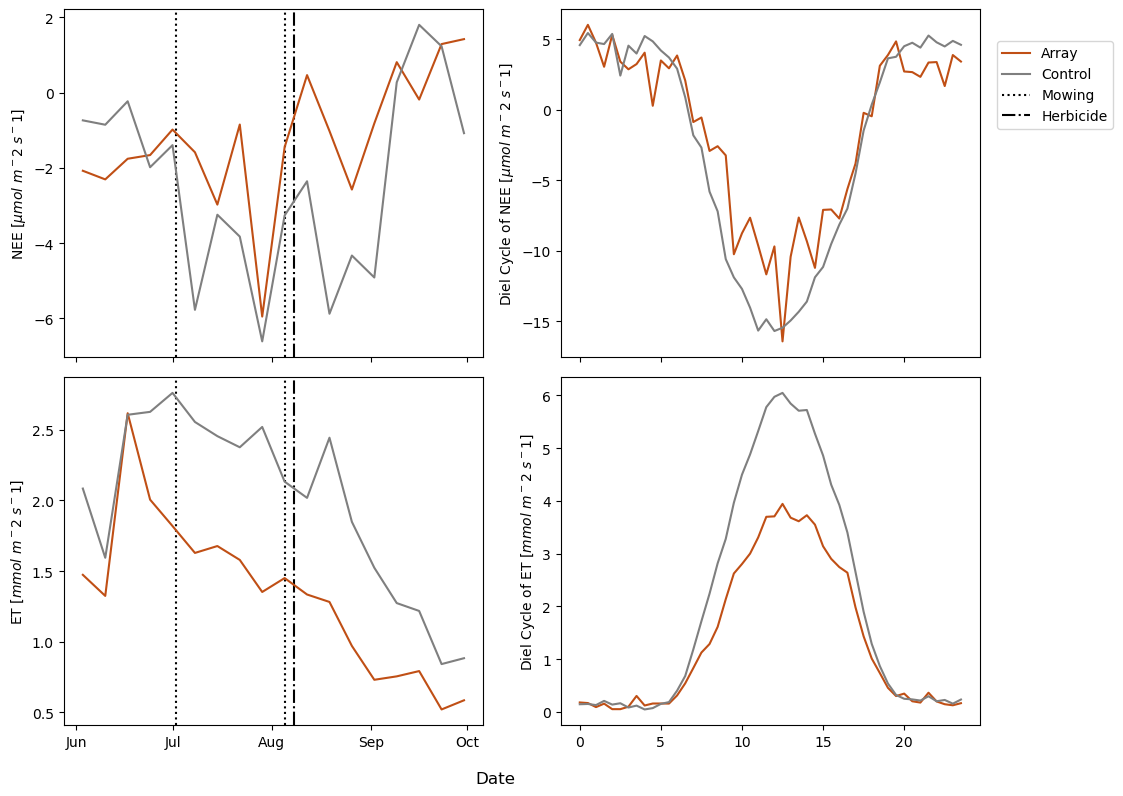

In [10]:
#Cumulative plot - 3 panels

#Change dates and variable
sd = dt.datetime(2025,6,1)
ed = dt.datetime(2025, 10, 1)
edex = dt.datetime(2025, 10, 2)

#[short var name, var name in dataframe, units, LE conversion factor, min val, max val, unit conversion for cumulative]
vardict = {'NEE': ['NEE', 'co2_flux', '[$\mu mol \ m^-2 \ s^-1$]','[$g \ m^-2$]', 1, -100, 100, 60 * 30 * 1e-6 * 44],
           'Evapotranspiration': ['ET', 'h2o_flux', '[$mmol \ m^-2 \ s^-1$]','[$mm$]', 1/2.5e3 * 1/18 * 1000, -100, 700, 60 * 30 * 1e-3 * 18 *1e-3],
}

# notes on unit conversions
# CO2
# unit_conv = 60 * 30 * 1e-6 * 44 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2
# H2O
# LE_cf = 1/2.5e3 * 1/1000 * 1/1000 * 1000 * 60 * 60 * 24 #[W/m^2] 
# LE_cf =  1/2.5e3 * 1/18 * 1000 #convert LE [W/m^2] to h2o flux [mmol/m^2/s] = 1/Latend heat of vaporization at 0C = 1/2.5e3 J/g * 1/1 mol/18 g* 1000mmol/mol
# unit_conv = 60 * 30 * 1e-3 * 18 *1e-3#[mmol/m^2/s] * 60 s/min * 30 min * 1 mol/10^3 mmol * 18 g/mol * 1kg/1000g * 1m^3/1000kg * 1000mm/m = [mm]- water vapor
# H
# unit_conv = 60 * 30 * 1e-6 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

#Create plot
figsize = (10, 8)
fig, axs = plt.subplots(2,2,  figsize = figsize, sharex = 'col')

#Add management as vertical lines on each plot
for ax in axs[:, 0]:
    m1 = ax.axvline(dt.datetime(2025, 7, 2), c = 'k', linestyle = ':', label = 'Mowing') #first mowing
    ax.axvline(dt.datetime(2025, 8, 5), c = 'k', linestyle = ':') #Second mowing
    m2 = ax.axvline(dt.datetime(2025, 8, 8), c = 'k', linestyle = '-.', label = 'Herbicide') #Herbacide


#Loop through variables, plot time series and cumulative plot for each
handles = [] #Empty list - later filled with legend labels
for i in range(2):

    var = list(vardict.keys())[i] #Long var name
    varname_short = vardict[var][0] #Shortened var name
    col = vardict[var][1] #column name in dataframe
    reg_units = vardict[var][2] #Units
    cum_units = vardict[var][3] #Units for cumulative plot
    ETtoLE = 1/vardict[var][4] #Conversion factor for converting between water flux units
    min_val = vardict[var][4]*vardict[var][5] #Min value for filtering
    max_val = vardict[var][4]*vardict[var][6] #Max val for filtering
    units_conv = vardict[var][7] #unit regular to cumulative units conversion factor - see code comments above for where these values come from

    #Filter based on min and max vals
    val_filter = (KSA[col]>=min_val) & (KSA[col]<=max_val) & (KSC[col]>=min_val) & (KSC[col]<=max_val)
    
    #Time series plot
    #Select left axis
    axl = axs[i, 0]

    #
    KSA_avg = day_avg(KSA[col].where(val_filter), avg_time = '7d')
    KSC_avg = day_avg(KSC[col].where(val_filter), avg_time = '7d')

    #Plot time series on left axis
    l1 = axl.plot(KSA_avg[sd:ed], label = 'Array', c = arraycolor)
    l2 = axl.plot(KSC_avg[sd:ed], label = 'Control', c = colordict['control'])

    axl.set_ylabel(varname_short  + ' ' + reg_units)

    #Cumulative plot
    #Right axis
    axr = axs[i, 1]

    #calculate cumulative values
    KSA_day_cyc = day_cyc(KSA[col].where(val_filter), sd = sd, ed = ed)
    KSC_day_cyc = day_cyc(KSC[col].where(val_filter), sd = sd, ed=ed)

    axr.set_ylabel('Diel Cycle of ' + varname_short  + ' ' + reg_units)
    

    axr.plot(hh_index, KSA_day_cyc, c = arraycolor)
    axr.plot(hh_index, KSC_day_cyc, c = colordict['control'])
   

    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0], m1, m2]


axl.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axl.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

# #Rotate tick labels
# for tick in axr.get_xticklabels():
#     tick.set_rotation(45)
# for tick in axl.get_xticklabels():
#     tick.set_rotation(45)
fig.supxlabel('Date')
# fig.suptitle('Fluxes June 1-October 1 2025')

#Add figure legend
fig.legend(handles, ['Array', 'Control', 'Mowing', 'Herbicide'], loc = 'upper right', bbox_to_anchor=(1.125, .95))

#Save figure
save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches='tight')

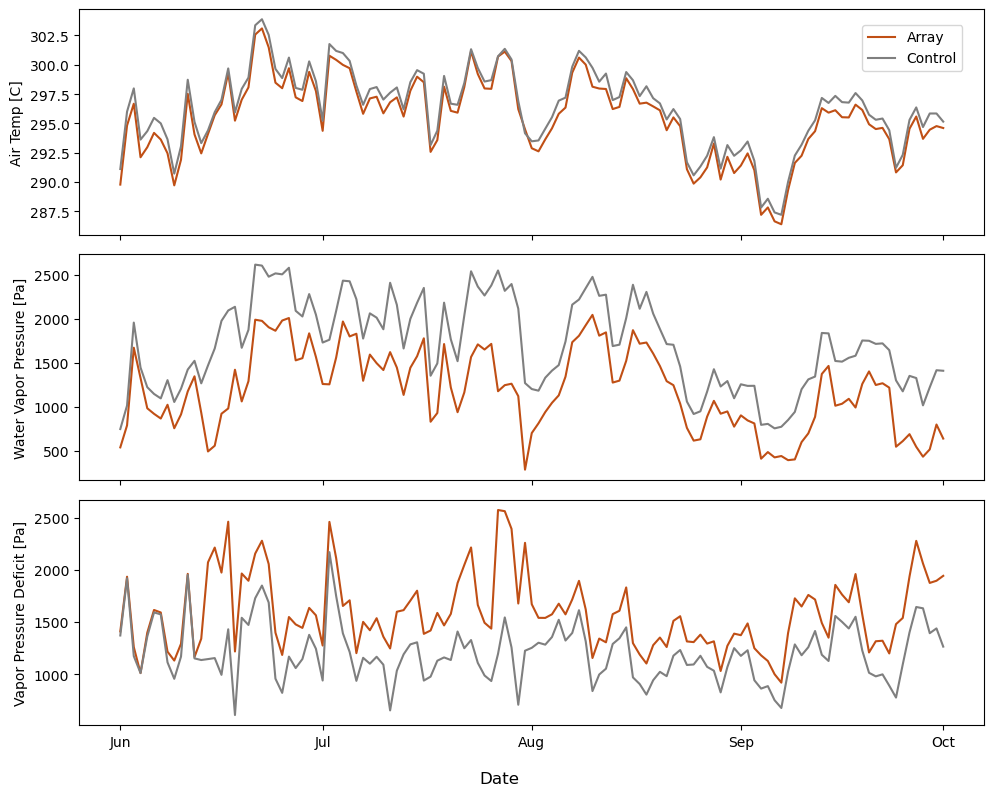

In [11]:
#Micromet Plot - 3 panels

#Change dates and variable
sd = dt.datetime(2025,6,1)
ed = dt.datetime(2025, 10, 1)
edex = dt.datetime(2025, 10, 2)

#[short var name, var name in dataframe, units, LE conversion factor, min val, max val, unit conversion for cumulative]
vardict = {'Air Temp': ['air_temperature', '[C]', 273, 323, -273],
           'Water Vapor Pressure': ['e', '[Pa]',  0, 4000, 0],
           'Vapor Pressure Deficit': ['VPD', '[Pa]', 0, 4000, 0]
}


#Create plot
figsize = (10,8)
fig, axs = plt.subplots(3,  figsize = figsize, sharex=True)

#Loop through variables, plot time series for each
handles = [] #Empty list - later filled with legend labels
for i in range(3):

    var = list(vardict.keys())[i] #Long var name
    col = vardict[var][0] #column name in dataframe
    reg_units = vardict[var][1]
    min_val = vardict[var][2]
    max_val = vardict[var][3]
    offset = vardict[var][4]


    #Filter based on min and max vals
    val_filter = (KSA[col]>=min_val) & (KSA[col]<=max_val) & (KSC[col]>=min_val) & (KSC[col]<=max_val)
    
    ax = axs[i]

    KSA_1dayavg = day_avg(KSA[col].where(val_filter), avg_time = '1d')
    KSC_1dayavg = day_avg(KSC[col].where(val_filter), avg_time = '1d')


    l1 = ax.plot(KSA_1dayavg[sd:ed], label = 'Array', c = arraycolor)
    l2 = ax.plot(KSC_1dayavg[sd:ed], label = 'Control', c = colordict['control'])

    ax.set_ylabel( var  + ' ' + reg_units) 


    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0]]



# Format x-axis to show only month names at the start of each month
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name


fig.supxlabel('Date')
# fig.suptitle('Micrometeorology June 1-October 1 2025')

#Add figure legend
fig.legend(handles, ['Array', 'Control'], loc = 'upper right', bbox_to_anchor=(.97, .97))

save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()

# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'micromet.png', bbox_inches='tight')

In [12]:
#Calculate vapor pressure and VPD for each tower and add to dataframe
def calc_VPD(tow_dat):
    RH = tow_dat['RH_1_1_1']
    TA = tow_dat['Ta_1_1_1']
    es = 611.2*np.exp(17.67*TA/(TA+ 243.5)) #Saturation vapor pressure [Pa] - Petty eqn 7.19 (pg 183)
    e = es*RH/100 #Vapor pressure [PA]
    VPD = es-e
    return e, VPD

for tow in [KSA_bm, KSC_bm, KSP_bm]:
    tow['e'], tow['VPD'] = calc_VPD(tow)


In [13]:
#Micromet plot - bm data

#Change dates and variable
sd = dt.datetime(2025,6,1)
ed = dt.datetime(2025, 10, 1)
edex = dt.datetime(2025, 10, 2)

#[short var name, var name in dataframe, units, LE conversion factor, min val, max val, unit conversion for cumulative]
# vardict = {'Air Temp': ['Ta_1_1_1', '[C]', 0, 50],
#            'Relative Humidity': ['RH_1_1_1', '[%]',  0, 100],
#            'Outgoing Longwave': ['LWout', '[$W \ m^-2$]', -50, 700]
# }

vardict = {'Air Temp': ['Ta_1_1_1', '[C]', 0, 50],
           'Relative Humidity': ['RH_1_1_1', '[%]',  0, 100],
           'Outgoing Longwave': ['LWout', '[$W \ m^-2$]', -50, 700]


#Create plot
figsize = (10,8)
fig, axs = plt.subplots(3,2,  figsize = figsize, sharex=True)


handles = []
for i in range(3):

    var = list(vardict.keys())[i] #Long var name
    col = vardict[var][0] #column name in dataframe
    reg_units = vardict[var][1]
    min_val = vardict[var][2]
    max_val = vardict[var][3]


    #Filter based on min and max vals
    val_filter = (KSA_bm[col]>=min_val) & (KSA_bm[col]<=max_val) & (KSC_bm[col]>=min_val) & (KSC_bm[col]<=max_val)
    
    axl = axs[i,0]
    axr = axs[i,1]

    KSA_1dayavg = day_avg(KSA_bm[col].where(val_filter), avg_time = '1d')
    KSC_1dayavg = day_avg(KSC_bm[col].where(val_filter), avg_time = '1d')
    RMSD = (((KSA_1dayavg - KSC_1dayavg)**2).mean())**(1/2)
    print(var, RMSD)


    l1 = axl.plot(KSA_1dayavg[sd:ed], label = 'Array', c = arraycolor)
    l2 = axl.plot(KSC_1dayavg[sd:ed], label = 'Control', c = colordict['control'])
    l3 = axr.axhline(0, c = 'k', alpha = 0.7, linestyle = '--')
    l3 = axr.plot(KSA_1dayavg[sd:ed] - KSC_1dayavg[sd:ed], label = 'Difference', c = 'k', alpha = 0.9)

    axl.set_ylabel( var  + ' ' + reg_units)


    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0], l3[0]]



# Format x-axis to show only month names at the start of each month
for ax in axs.flatten():
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name


fig.supxlabel('Date')
# fig.suptitle('Micrometeorology June 1-October 1 2025')

#Add figure legend
fig.legend(handles, ['Array', 'Control', 'Difference'], loc = 'upper right', bbox_to_anchor=(1.125, .97))

save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()

# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'micromet.png', bbox_inches='tight')

<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_24804\128614602.py:16: SyntaxWarning: invalid escape sequence '\ '
  'Outgoing Longwave': ['LWout', '[$W \ m^-2$]', -50, 700]


SyntaxError: '{' was never closed (128614602.py, line 14)

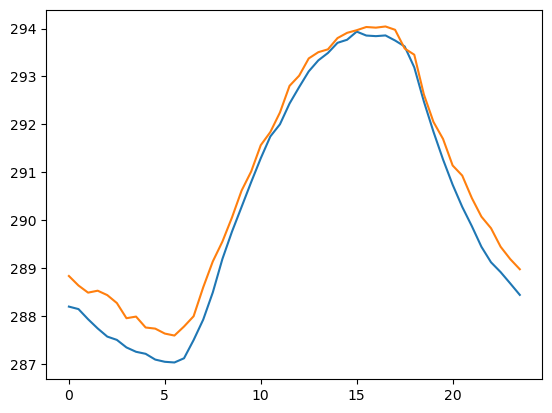

In [ ]:
plt.plot(hh_index, day_cyc(KSA['air_temperature'], minval = 273, maxval = 323))
plt.plot(hh_index, day_cyc(KSC['air_temperature'], minval = 273, maxval = 323))

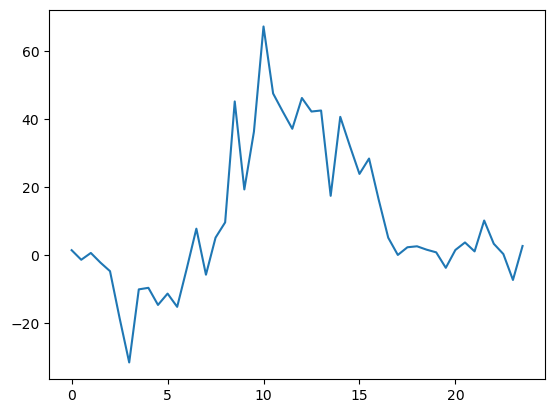

In [ ]:
sdc = dt.datetime(2025,9,1)
edc = dt.datetime(2025, 10, 1)
KSA_dc = day_cyc(KSA[sdc:edc])
KSC_dc = day_cyc(KSC[sdc:edc])

# var = 'LE'

# plt.plot(hh_index, KSA_dc[var] - KSC_dc[var])
# plt.plot(hh_index, KSA_dc[var])
# plt.plot(hh_index, KSC_dc[var])



plt.plot(hh_index, KSC_dc["LE"] + KSC_dc["H"] - KSA_dc['LE'] - KSA_dc["H"])


<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\3060512144.py:25: SyntaxWarning: invalid escape sequence '\m'
  cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\3060512144.py:39: SyntaxWarning: invalid escape sequence '\ '
  cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\3060512144.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


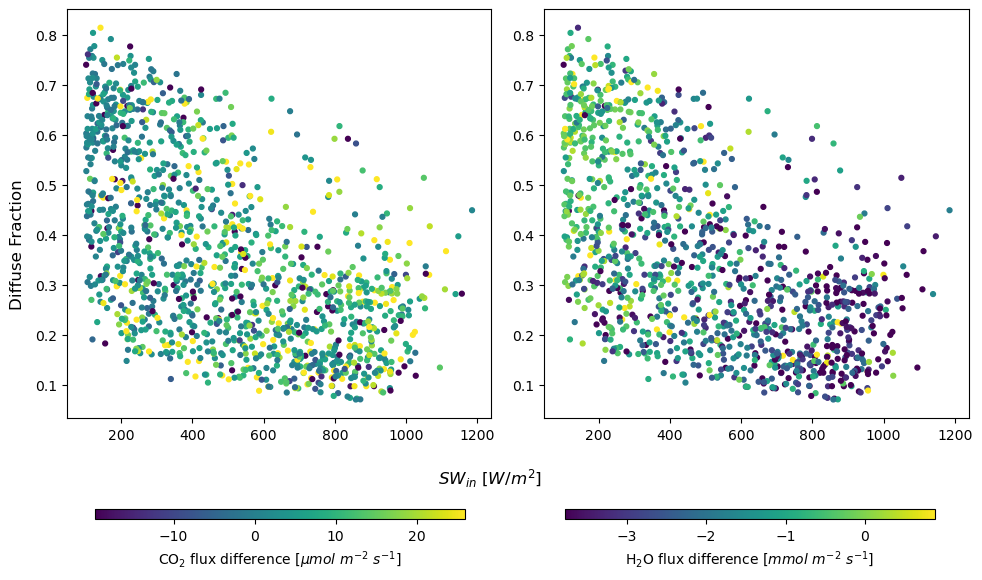

In [ ]:
#Tomorrow: Move colorbar
#Idea for later: make this more like heat map with average flux values in each box rather than individual dots

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
sdc = dt.datetime(2025, 7, 15)
edc = dt.datetime(2025, 9, 15)

quant_cut = 0.05

flux_diff = KSA_flux-KSC_flux
filter = KSA_SWin[sdc:edc]>100

ax = axs[0]
var = 'co2_flux'
im = ax.scatter(KSA_SWin[sdc:edc][filter], 
        1-Sdir_frac[sdc:edc][filter], 
        c = flux_diff[var][sdc:edc][filter],
        s = 12,
        cmap = 'viridis',
        vmin = flux_diff[var].quantile(quant_cut),
        vmax = flux_diff[var].quantile(1-quant_cut))
# ax.set_title('CO2 Flux Difference')
cax = fig.add_axes([0.105, -.05, 0.37, 0.02])
cb = plt.colorbar(im, orientation = 'horizontal', cax = cax)
cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')

ax = axs[1]
var = 'h2o_flux'
im = ax.scatter(KSA_SWin[sdc:edc][filter], 
        1-Sdir_frac[sdc:edc][filter], 
        c = flux_diff[var][sdc:edc][filter],
        s = 12,
        cmap = 'viridis',
        vmin = flux_diff[var].quantile(quant_cut),
        vmax = flux_diff[var].quantile(1-quant_cut))
# ax.set_title('H2O Flux Difference')
cax = fig.add_axes([0.575, -.05, 0.37, 0.02])
cb = plt.colorbar(im, orientation = 'horizontal', cax = cax)
cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')


fig.supylabel('Diffuse Fraction')
fig.supxlabel('$SW_{in}$ [$W/m^2$]')
fig.tight_layout()
# cbar_ax = fig.add_axes([.92, 0.15, 0.02, 0.7])
# plt.colorbar(cb, cbar_ax, label = 'CO2 flux [$\mu mol/{m^2 s}$]')
plt.savefig(save_base_path + 'SWin_dirfrac_and_flux.png')

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\ '
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\2272907809.py:46: SyntaxWarning: invalid escape sequence '\m'
  cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\2272907809.py:70: SyntaxWarning: invalid escape sequence '\ '
  cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\2272907809.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


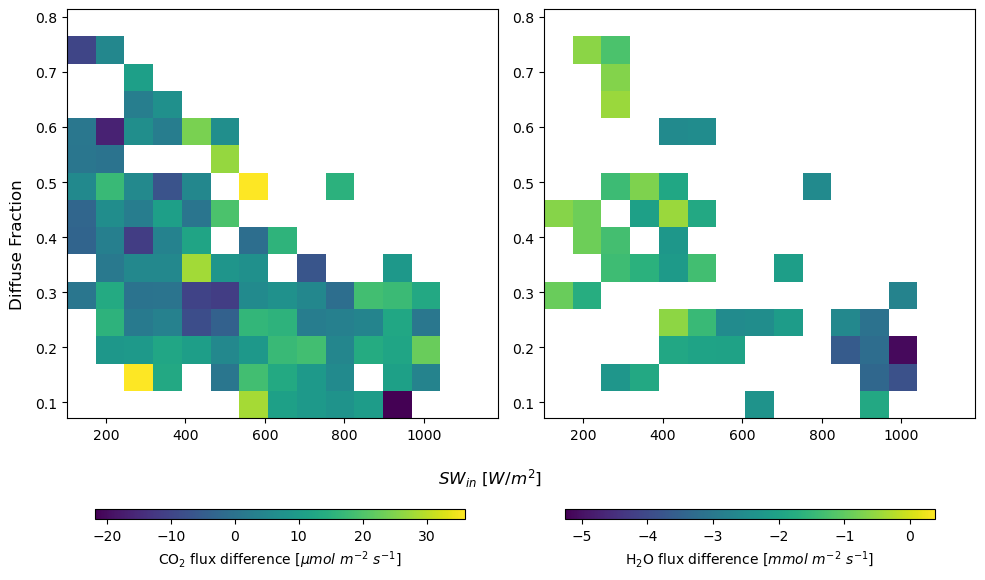

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sdc = dt.datetime(2025, 7, 15)
edc = dt.datetime(2025, 9, 15)

quant_cut = 0.05

flux_diff = KSA_flux - KSC_flux
filter = KSA_SWin[sdc:edc] > 100

# Define number of bins for the heat map
n_bins_x = 15
n_bins_y = 15
min_points = 5

# Prepare data
x_data = KSA_SWin[sdc:edc][filter].values
y_data = (1 - Sdir_frac[sdc:edc][filter]).values

# CO2 flux
ax = axs[0]
var = 'co2_flux'
z_data = flux_diff[var][sdc:edc][filter].values

# Create 2D bins
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins_x + 1)
y_bins = np.linspace(y_data.min(), y_data.max(), n_bins_y + 1)

# Calculate average values and counts in each bin
z_mean = np.full((n_bins_y, n_bins_x), np.nan)
for i in range(n_bins_x):
    for j in range(n_bins_y):
        mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
                (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
        if mask.sum() >= min_points:
            z_mean[j, i] = z_data[mask].mean()

# Create heat map
vmin = np.nanquantile(z_data, quant_cut)
vmax = np.nanquantile(z_data, 1 - quant_cut)
im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
               extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
               vmin=vmin, vmax=vmax)

cax = fig.add_axes([0.105, -0.05, 0.37, 0.02])
cb = plt.colorbar(im, orientation='horizontal', cax=cax)
cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')

# H2O flux
ax = axs[1]
var = 'h2o_flux'
z_data = flux_diff[var][sdc:edc][filter].values

# Calculate average values in each bin
z_mean = np.full((n_bins_y, n_bins_x), np.nan)
for i in range(n_bins_x):
    for j in range(n_bins_y):
        mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
                (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
        if mask.sum() >= min_points:
            z_mean[j, i] = z_data[mask].mean()

vmin = np.nanquantile(z_data, quant_cut)
vmax = np.nanquantile(z_data, 1 - quant_cut)
im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
               extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
               vmin=vmin, vmax=vmax)

cax = fig.add_axes([0.575, -0.05, 0.37, 0.02])
cb = plt.colorbar(im, orientation='horizontal', cax=cax)
cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')

fig.supylabel('Diffuse Fraction')
fig.supxlabel('$SW_{in}$ [$W/m^2$]')
fig.tight_layout()
plt.savefig(save_base_path + 'SWin_dirfrac_and_flux.png')

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\ '
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\3992789999.py:57: SyntaxWarning: invalid escape sequence '\m'
  cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\3992789999.py:90: SyntaxWarning: invalid escape sequence '\ '
  cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')
C:\Users\emily\AppData\Local\Temp\ipykernel_20640\3992789999.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


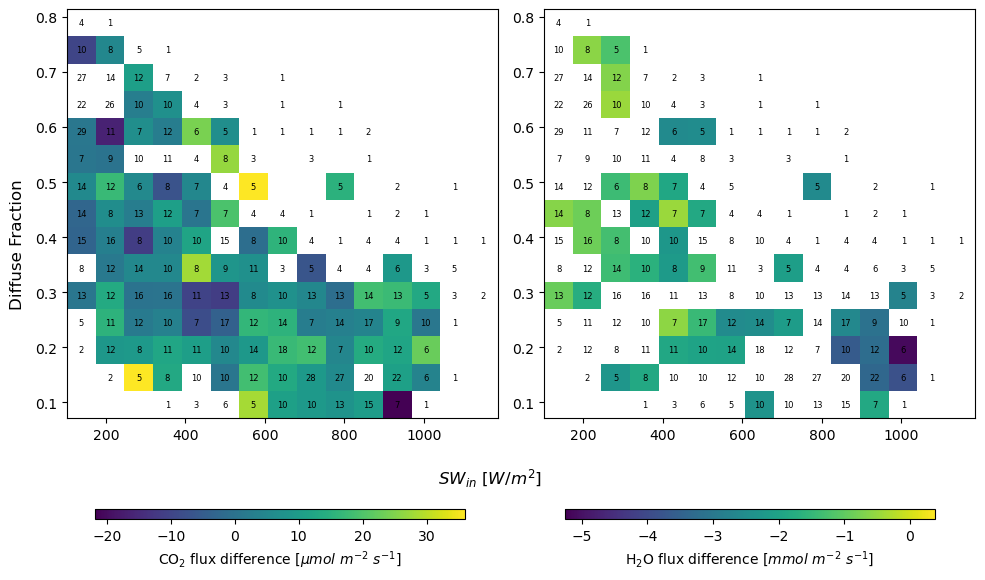

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sdc = dt.datetime(2025, 7, 15)
edc = dt.datetime(2025, 9, 15)

quant_cut = 0.05

flux_diff = KSA_flux - KSC_flux
filter = KSA_SWin[sdc:edc] > 100

# Define number of bins for the heat map
n_bins_x = 15
n_bins_y = 15
min_points = 5

# Prepare data
x_data = KSA_SWin[sdc:edc][filter].values
y_data = (1 - Sdir_frac[sdc:edc][filter]).values

# Create 2D bins
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins_x + 1)
y_bins = np.linspace(y_data.min(), y_data.max(), n_bins_y + 1)

# CO2 flux
ax = axs[0]
var = 'co2_flux'
z_data = flux_diff[var][sdc:edc][filter].values

# Calculate average values and counts in each bin
z_mean = np.full((n_bins_y, n_bins_x), np.nan)
counts = np.zeros((n_bins_y, n_bins_x), dtype=int)
for i in range(n_bins_x):
    for j in range(n_bins_y):
        mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
                (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
        counts[j, i] = mask.sum()
        if counts[j, i] >= min_points:
            z_mean[j, i] = z_data[mask].mean()

# Create heat map
vmin = np.nanquantile(z_data, quant_cut)
vmax = np.nanquantile(z_data, 1 - quant_cut)
im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
               extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
               vmin=vmin, vmax=vmax)

# Add text annotations with counts
x_centers = (x_bins[:-1] + x_bins[1:]) / 2
y_centers = (y_bins[:-1] + y_bins[1:]) / 2
for i in range(n_bins_x):
    for j in range(n_bins_y):
        if counts[j, i] > 0:
            ax.text(x_centers[i], y_centers[j], str(counts[j, i]),
                   ha='center', va='center', fontsize=6, color='k')

cax = fig.add_axes([0.105, -0.05, 0.37, 0.02])
cb = plt.colorbar(im, orientation='horizontal', cax=cax)
cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')

# H2O flux
ax = axs[1]
var = 'h2o_flux'
z_data = flux_diff[var][sdc:edc][filter].values

# Calculate average values and counts in each bin
z_mean = np.full((n_bins_y, n_bins_x), np.nan)
counts = np.zeros((n_bins_y, n_bins_x), dtype=int)
for i in range(n_bins_x):
    for j in range(n_bins_y):
        mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
                (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
        counts[j, i] = mask.sum()
        if counts[j, i] >= min_points:
            z_mean[j, i] = z_data[mask].mean()

vmin = np.nanquantile(z_data, quant_cut)
vmax = np.nanquantile(z_data, 1 - quant_cut)
im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
               extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
               vmin=vmin, vmax=vmax)

# Add text annotations with counts
for i in range(n_bins_x):
    for j in range(n_bins_y):
        if counts[j, i] > 0:
            ax.text(x_centers[i], y_centers[j], str(counts[j, i]),
                   ha='center', va='center', fontsize=6, color='k')

cax = fig.add_axes([0.575, -0.05, 0.37, 0.02])
cb = plt.colorbar(im, orientation='horizontal', cax=cax)
cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')

fig.supylabel('Diffuse Fraction')
fig.supxlabel('$SW_{in}$ [$W/m^2$]')
fig.tight_layout()
plt.savefig(save_base_path + 'SWin_dirfrac_and_flux.png')

# Code Junkyard

In [ ]:
# #Code from for plotting each separately with details about unit conversions

# #CO2 Flux
# varname = 'NEE'
# varname_short = varname
# cum_units = '[$g/m^2$]'
# var = 'co2_flux'
# min_val = -100 #From DFC limits(from AFlux?)
# max_val = 100 #From DFC limits(from AFlux?)
# unit_conv = 60 * 30 * 1e-6 * 44 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

# #H2O flux
# varname = 'Evapotranspiration'
# varname_short = 'ET'
# cum_units = '[$mm$]'
# var = 'h2o_flux'
# LE_cf =  1/2.5e3 * 1/18 * 1000 #convert LE [W/m^2] to h2o flux [mmol/m^2/s] = 1/Latend heat of vaporization at 0C = 1/2.5e3 J/g * 1/1 mol/18 g* 1000mmol/mol
# min_val = -100*LE_cf# DFC limits(from Ankur)
# max_val = 700*LE_cf #From DFC limits (from Ankur)
# unit_conv = 60 * 30 * 1e-3 * 18 *1e-3#[mmol/m^2/s] * 60 s/min * 30 min * 1 mol/10^3 mmol * 18 g/mol * 1kg/1000g * 1m^3/1000kg * 1000mm/m = [mm]- water vapor

#Alternate for presenting ET in mm/day
# LE_cf = 1/2.5e3 * 1/1000 * 1/1000 * 1000 * 60 * 60 * 24 #[W/m^2] 


# #H Flux
# varname = 'Sensible Heat Flux'
# varname_short = 'H'
# cum_units = '[$MJ/m^2$]'
# var = 'H'
# min_val = -100 #From DFC limits(from AFlux?)
# max_val = 700 #From DFC limits(from AFlux?)
# unit_conv = 60 * 30 * 1e-6 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

In [ ]:
# #Cumulative plot - 3 panels

# #Change dates and variable
# sd = dt.datetime(2025,6,1)
# ed = dt.datetime(2025, 10, 1)
# edex = dt.datetime(2025, 10, 2)

# #[short var name, var name in dataframe, units, LE conversion factor, min val, max val, unit conversion for cumulative]
# vardict = {'NEE': ['NEE', 'co2_flux', '[$\mu mol \ m^-2 \ s^-1$]','[$g \ m^-2$]', 1, -100, 100, 60 * 30 * 1e-6 * 44],
#            'Evapotranspiration': ['ET', 'h2o_flux', '[$mmol \ m^-2 \ s^-1$]','[$mm$]', 1/2.5e3 * 1/18 * 1000, -100, 700, 60 * 30 * 1e-3 * 18 *1e-3],
#            'Sensible Heat Flux': ['H', 'H', '$[W \ m^-2$]','[$MJ \ m^-2$]', 1, -100, 700, 60 * 30 * 1e-6]
# }

# #notes on unit conversions
# # CO2
# # unit_conv = 60 * 30 * 1e-6 * 44 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2
# # H2O
# # LE_cf = 1/2.5e3 * 1/1000 * 1/1000 * 1000 * 60 * 60 * 24 #[W/m^2] 
# # LE_cf =  1/2.5e3 * 1/18 * 1000 #convert LE [W/m^2] to h2o flux [mmol/m^2/s] = 1/Latend heat of vaporization at 0C = 1/2.5e3 J/g * 1/1 mol/18 g* 1000mmol/mol
# # unit_conv = 60 * 30 * 1e-3 * 18 *1e-3#[mmol/m^2/s] * 60 s/min * 30 min * 1 mol/10^3 mmol * 18 g/mol * 1kg/1000g * 1m^3/1000kg * 1000mm/m = [mm]- water vapor
# # H
# # unit_conv = 60 * 30 * 1e-6 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

# #Create plot
# figsize = (10,8)
# fig, axs = plt.subplots(3,2,  figsize = figsize, sharex=True)

# #Add management as vertical lines on each plot
# for ax in axs.flatten():
#     m1 = ax.axvline(dt.datetime(2025, 7, 2), c = 'k', linestyle = ':', label = 'Mowing') #first mowing
#     ax.axvline(dt.datetime(2025, 8, 5), c = 'k', linestyle = ':') #Second mowing
#     m2 = ax.axvline(dt.datetime(2025, 8, 8), c = 'k', linestyle = '-.', label = 'Herbicide') #Herbacide


# #Loop through variables, plot time series and cumulative plot for each
# handles = [] #Empty list - later filled with legend labels
# for i in range(3):

#     var = list(vardict.keys())[i] #Long var name
#     varname_short = vardict[var][0] #Shortened var name
#     col = vardict[var][1] #column name in dataframe
#     reg_units = vardict[var][2] #Units
#     cum_units = vardict[var][3] #Units for cumulative plot
#     ETtoLE = 1/vardict[var][4] #Conversion factor for converting between water flux units
#     min_val = vardict[var][4]*vardict[var][5] #Min value for filtering
#     max_val = vardict[var][4]*vardict[var][6] #Max val for filtering
#     units_conv = vardict[var][7] #unit regular to cumulative units conversion factor - see code comments above for where these values come from

#     #Filter based on min and max vals
#     val_filter = (KSA[col]>=min_val) & (KSA[col]<=max_val) & (KSC[col]>=min_val) & (KSC[col]<=max_val)
    
#     #Time series plot
#     #Select left axis
#     axl = axs[i, 0]

#     #
#     KSA_1dayavg = day_avg(KSA[col].where(val_filter), avg_time = '1d')
#     KSC_1dayavg = day_avg(KSC[col].where(val_filter), avg_time = '1d')

#     #Plot time series on left axis
#     l1 = axl.plot(KSA_1dayavg[sd:ed], label = 'Array', c = arraycolor)
#     l2 = axl.plot(KSC_1dayavg[sd:ed], label = 'Control', c = colordict['control'])

#     axl.set_ylabel( varname_short  + ' ' + reg_units)

#     #Cumulative plot
#     #Right axis
#     axr = axs[i, 1]

#     #calculate cumulative values
#     KSA_cum = KSA[col].where(val_filter)[sd:ed].cumsum()*units_conv
#     KSC_cum = KSC[col].where(val_filter)[sd:ed].cumsum()*units_conv
#     # ax.plot(KSA_cum)
#     # ax.plot(KSC_cum)

#     axr.set_ylabel('Cumulative ' + varname_short  + ' ' + cum_units)
    

#     axr.plot(KSA_cum, label = 'Array', c = arraycolor)
#     axr.plot(KSC_cum, label = 'Control', c = colordict['control'])
#     print(varname_short, KSA_cum[-1]/KSC_cum[-1])

#     if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
#         handles = [l1[0], l2[0], m1, m2]

# for ax in [axl, axr]:
#     ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

# # #Rotate tick labels
# # for tick in axr.get_xticklabels():
# #     tick.set_rotation(45)
# # for tick in axl.get_xticklabels():
# #     tick.set_rotation(45)
# fig.supxlabel('Date')
# # fig.suptitle('Fluxes June 1-October 1 2025')

# #Add figure legend
# fig.legend(handles, ['Array', 'Control', 'Mowing', 'Herbicide'], loc = 'upper right', bbox_to_anchor=(1.125, .95))

# #Save figure
# save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
# fig.tight_layout()
# # plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches='tight')